In [4]:
import pandas as pd
import seaborn as sbn
import matplotlib.pyplot as pylt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import numpy as np
import joblib


In [5]:
# DATA ANALYSIS
# Load the dataset, EDA
df = pd.read_csv('PCOS_data.csv')

# Display the first few rows, EDA
print(df.head())
# Check data types, EDA
print(df.dtypes)
# Check for duplicates, EDA
duplicates = df.duplicated().sum
print(f"Number of duplicate records: {duplicates}")  # no duplicates
# Count Unique Values
print(df['PCOS (Y/N)'].value_counts())
print(df['Weight gain(Y/N)'].value_counts())

   Sl. No  Patient File No.  PCOS (Y/N)   Age (yrs)  Weight (Kg)  Height(Cm)   \
0       1                 1           0          28         44.6        152.0   
1       2                 2           0          36         65.0        161.5   
2       3                 3           1          33         68.8        165.0   
3       4                 4           0          37         65.0        148.0   
4       5                 5           0          25         52.0        161.0   

    BMI  Blood Group  Pulse rate(bpm)   RR (breaths/min)  ...  \
0  19.3           15                78                22  ...   
1  24.9           15                74                20  ...   
2  25.3           11                72                18  ...   
3  29.7           13                72                20  ...   
4  20.1           11                72                18  ...   

   Reg.Exercise(Y/N)  BP _Systolic (mmHg)  BP _Diastolic (mmHg)  \
0                  0                  110              

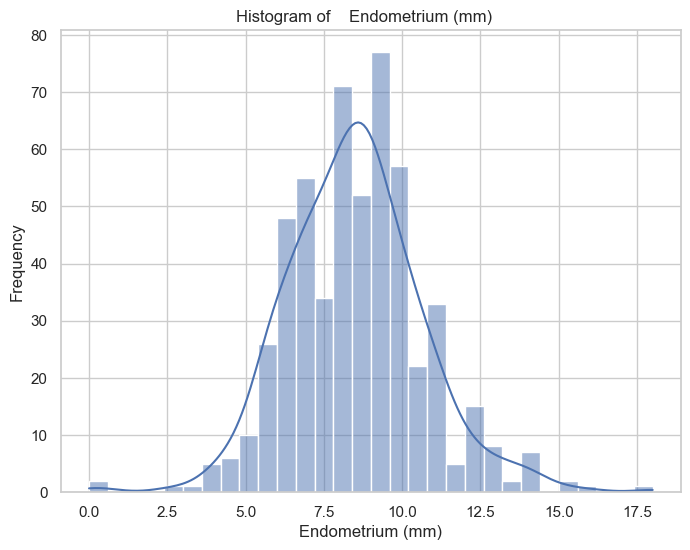

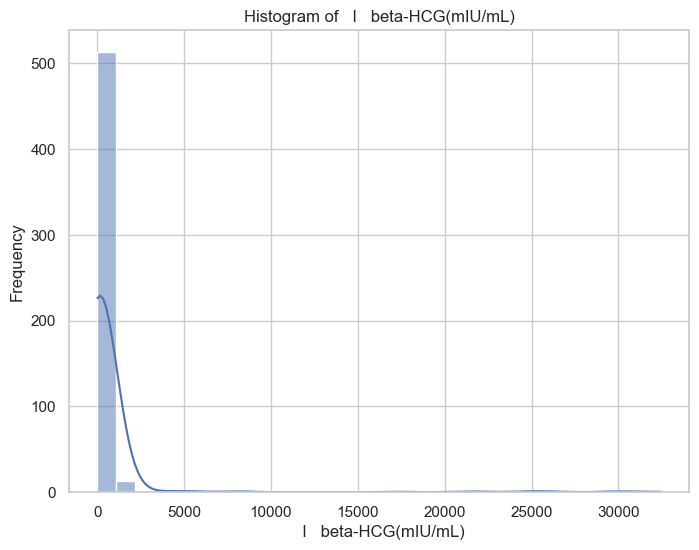

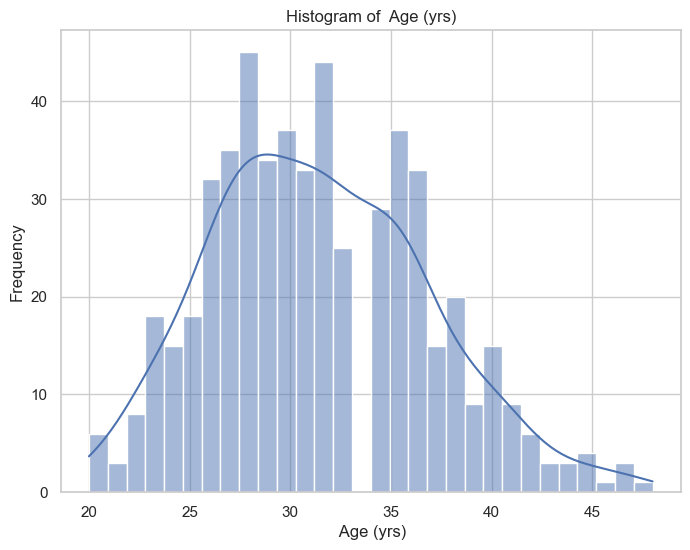

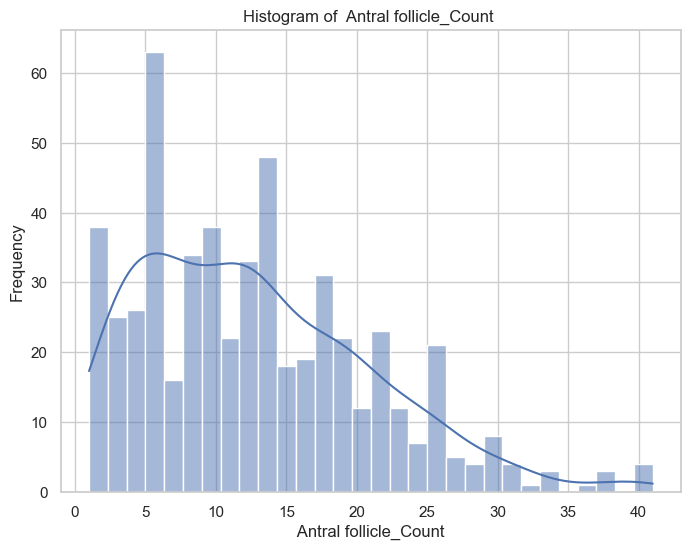

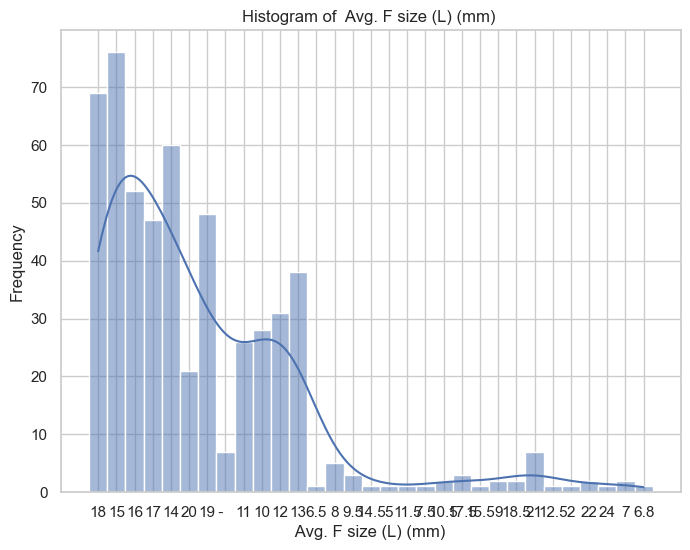

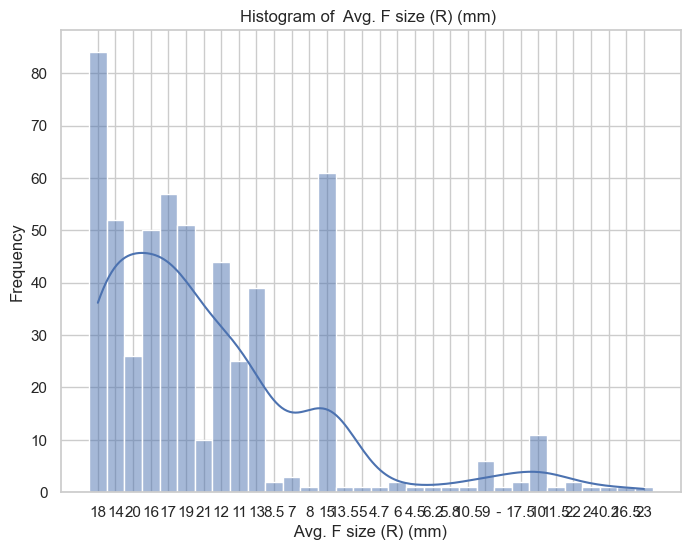

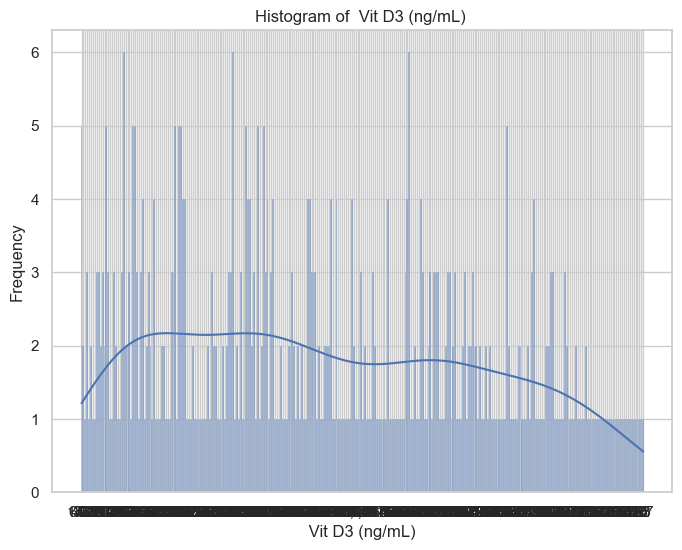

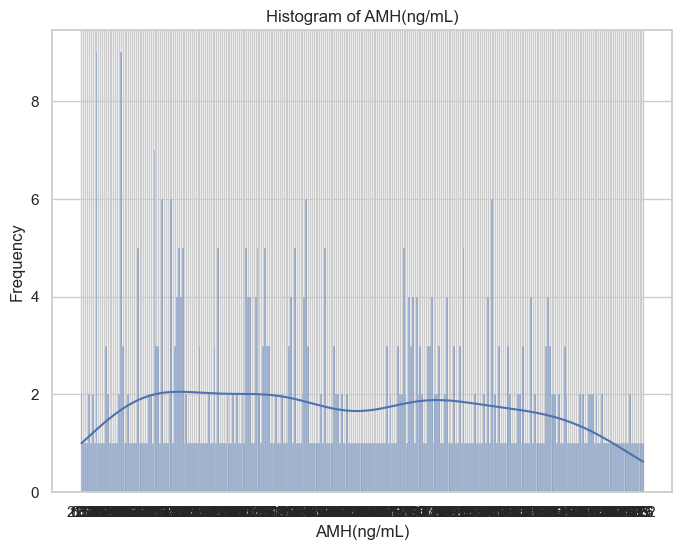

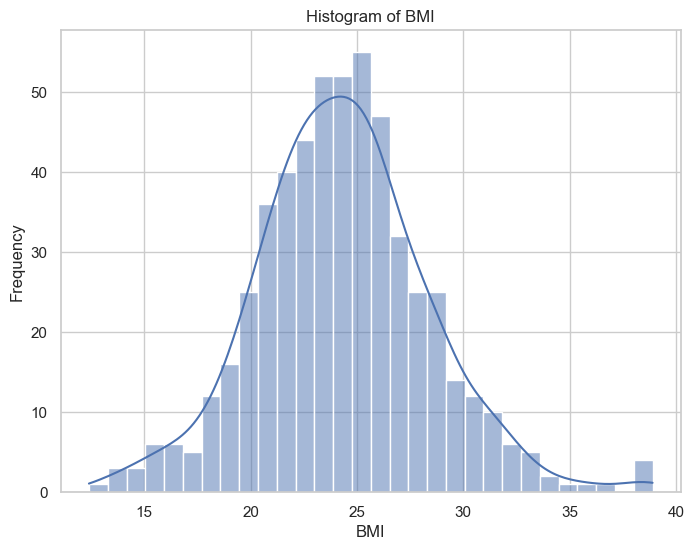

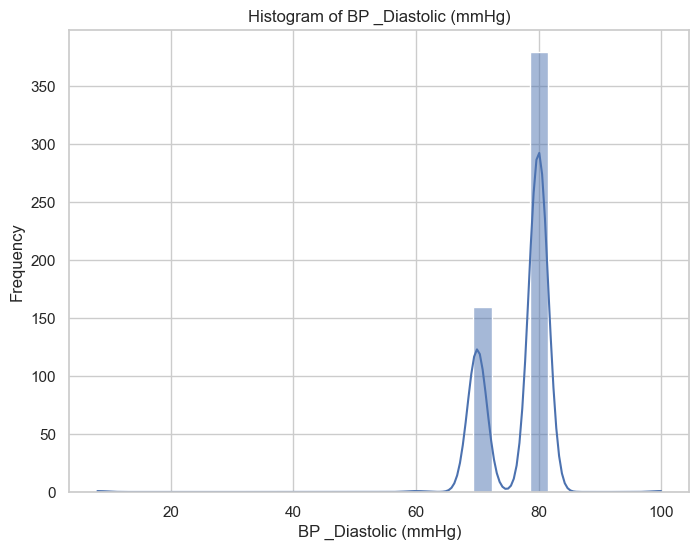

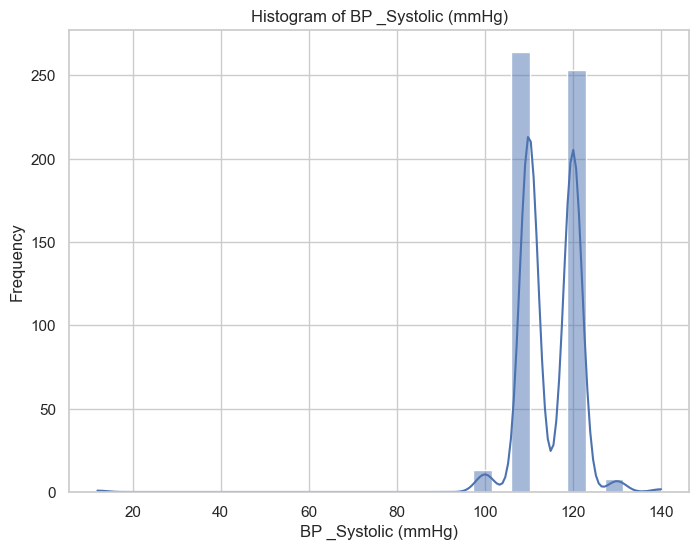

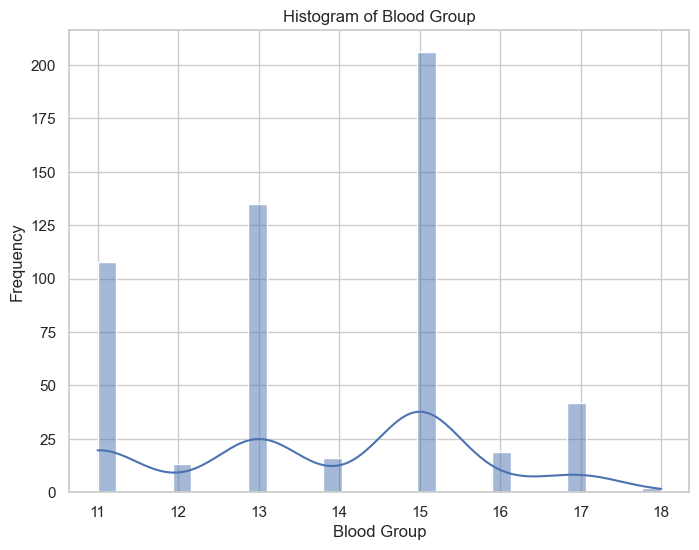

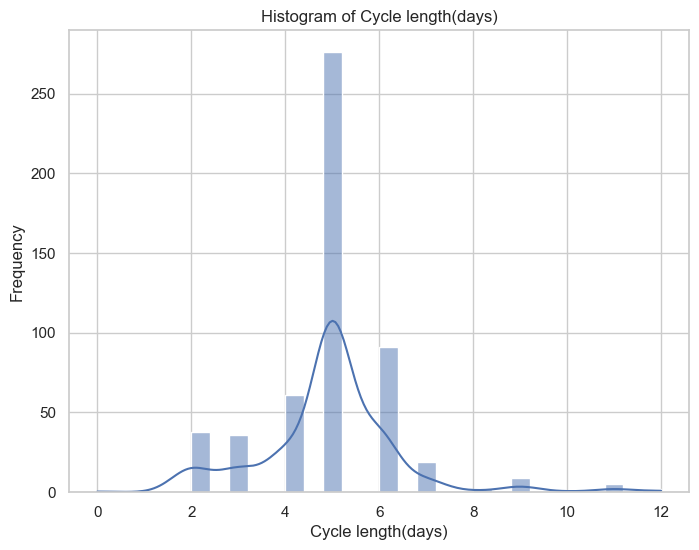

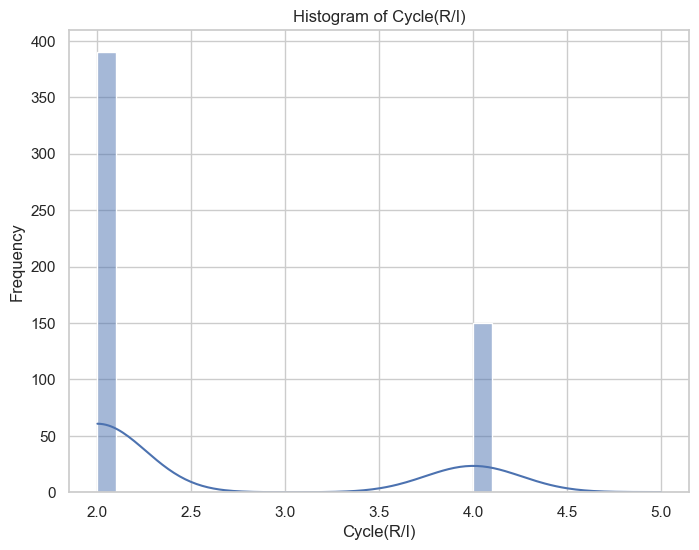

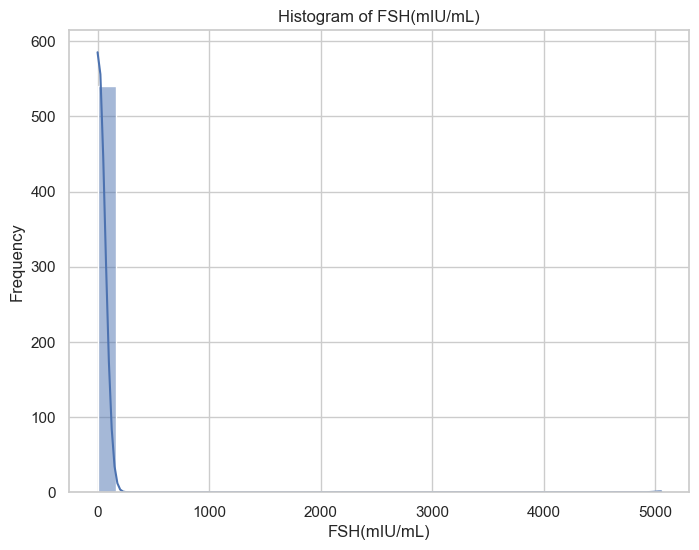

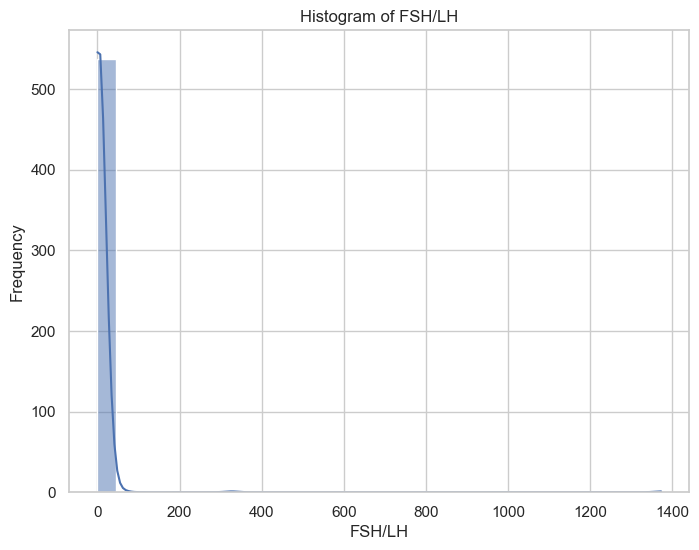

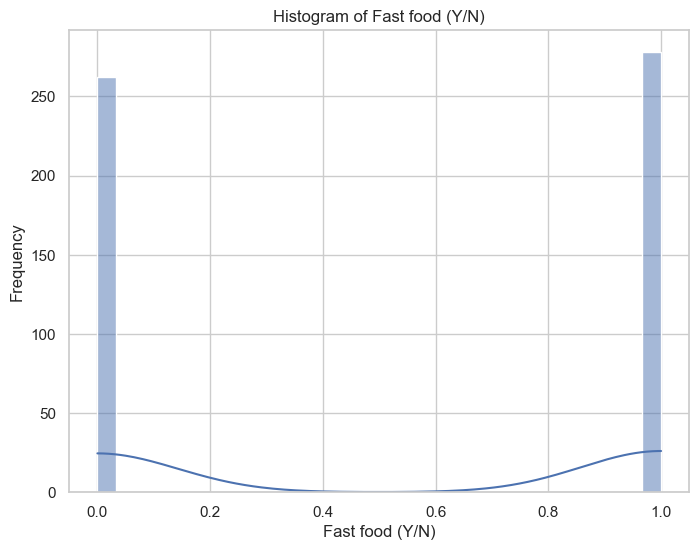

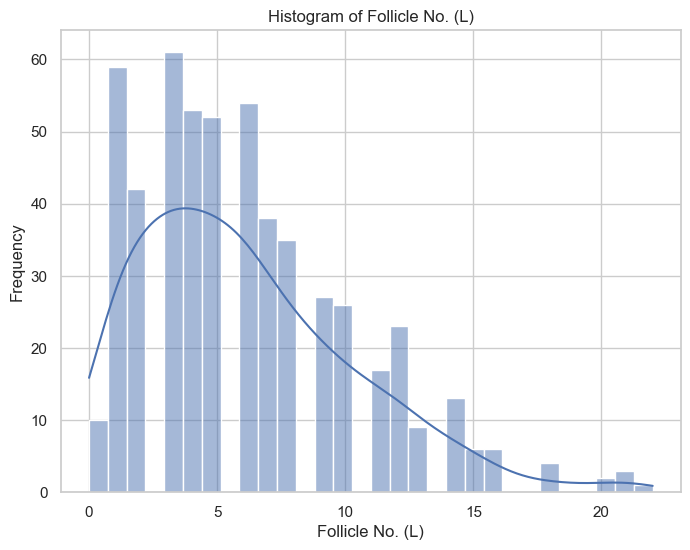

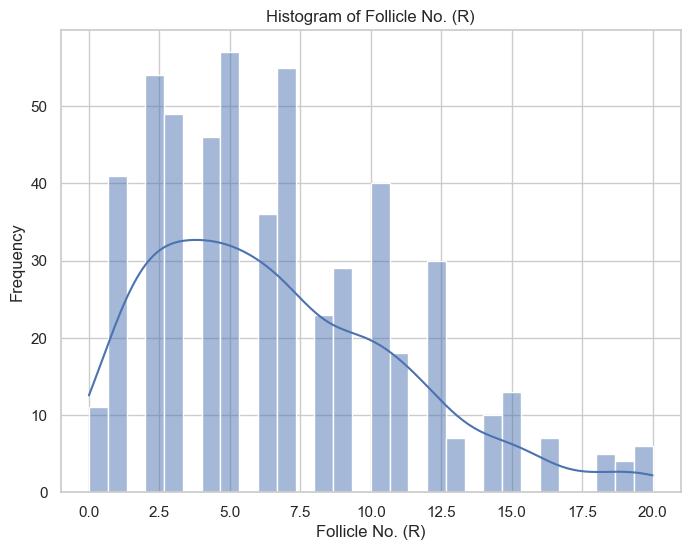

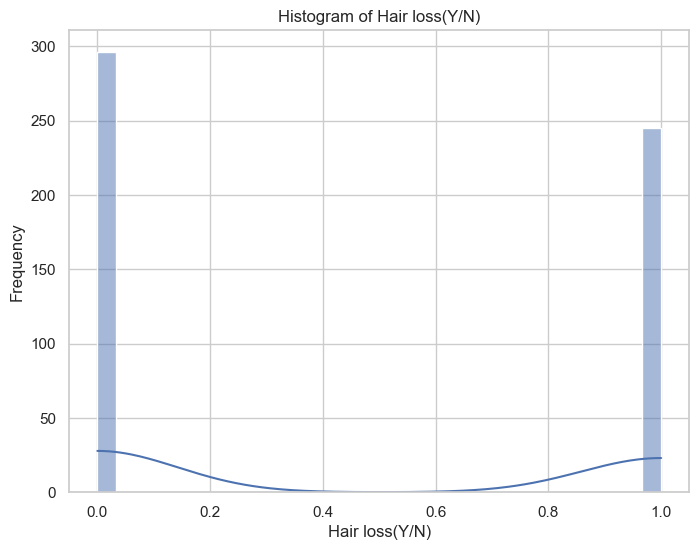

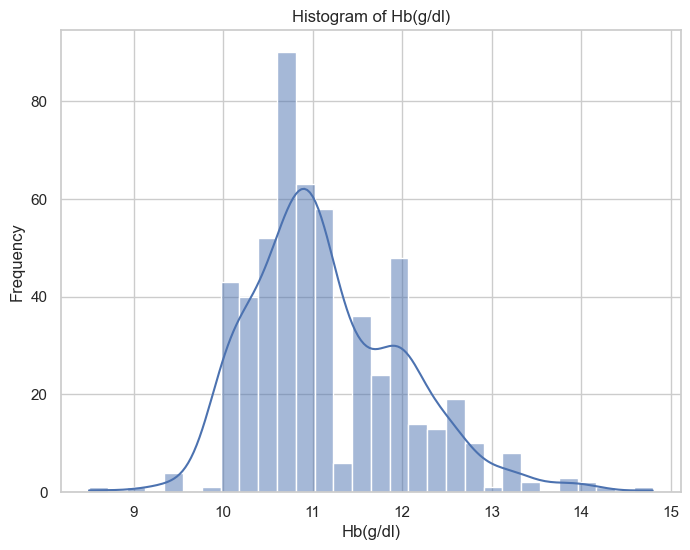

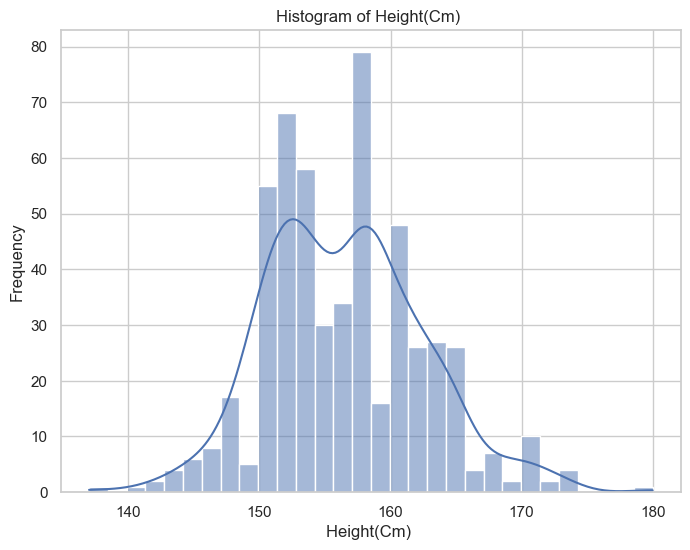

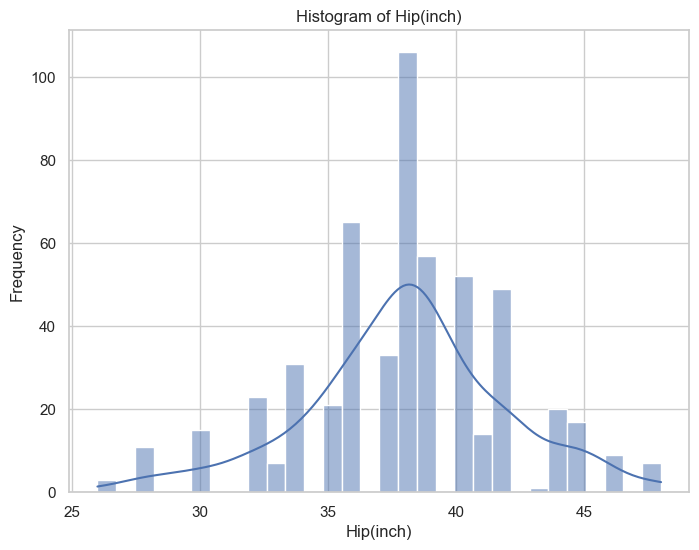

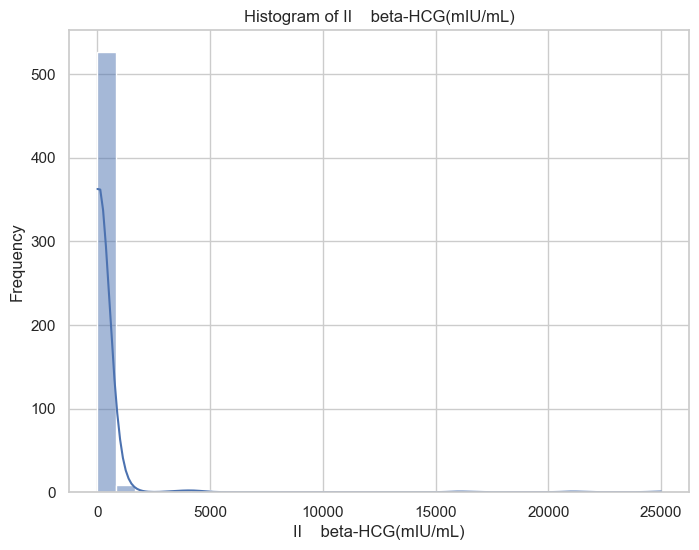

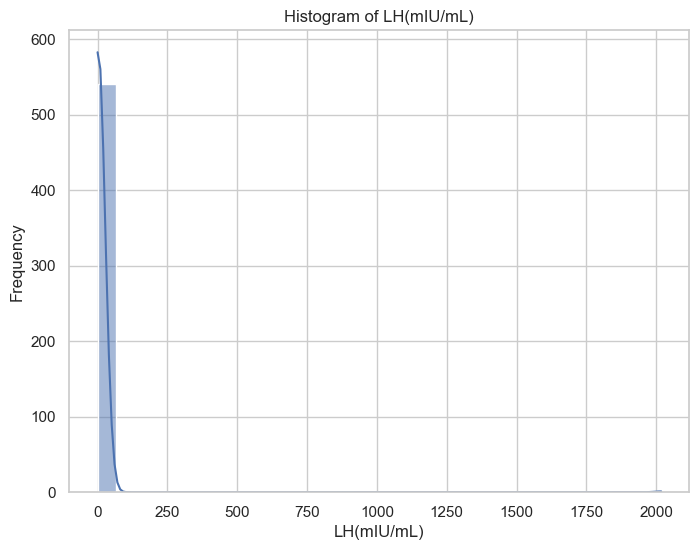

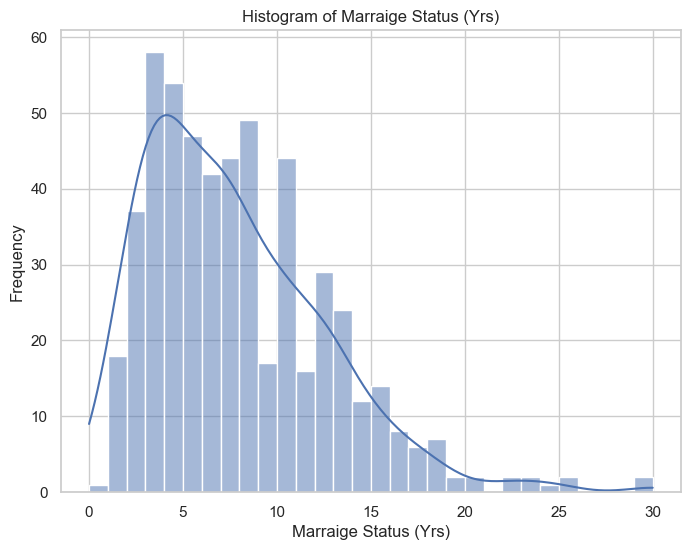

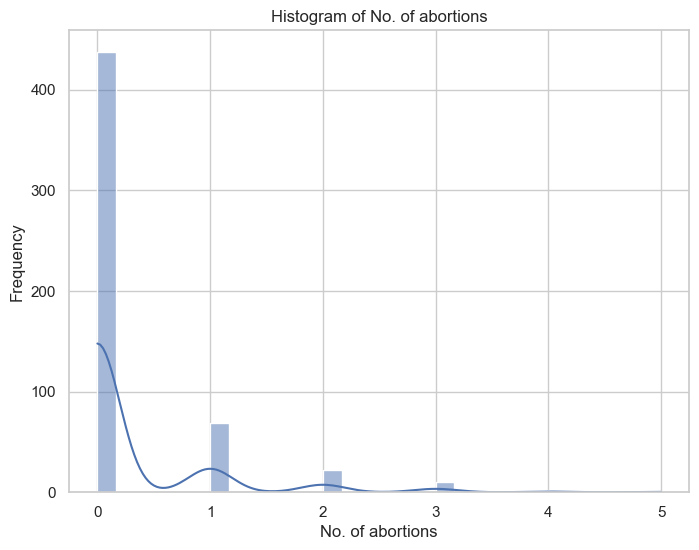

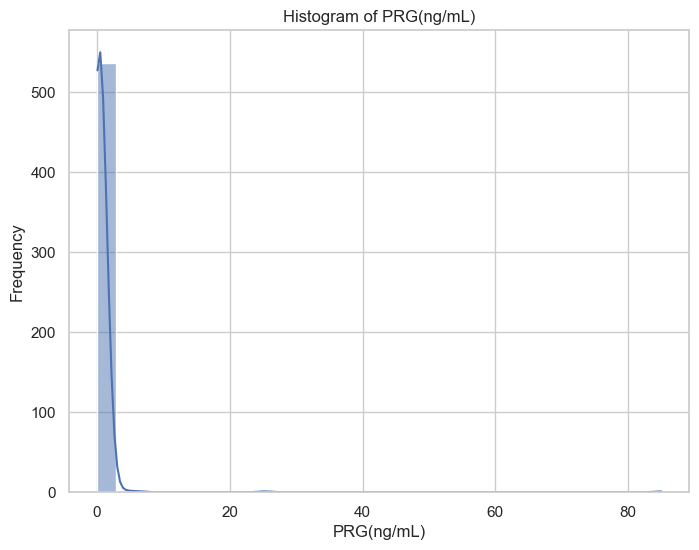

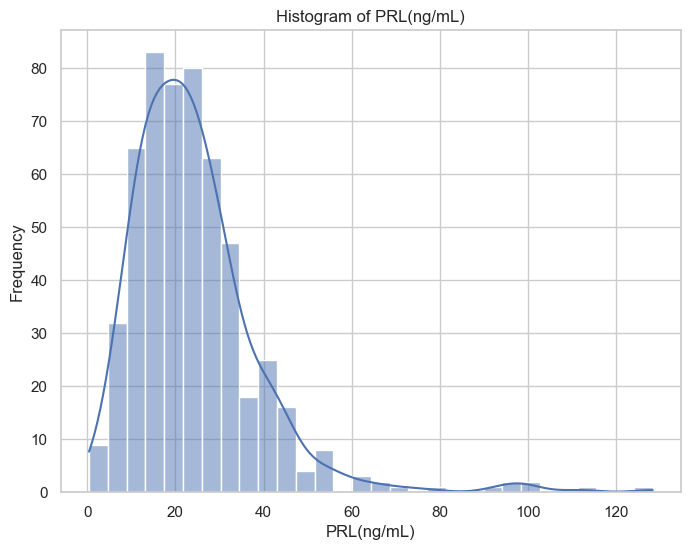

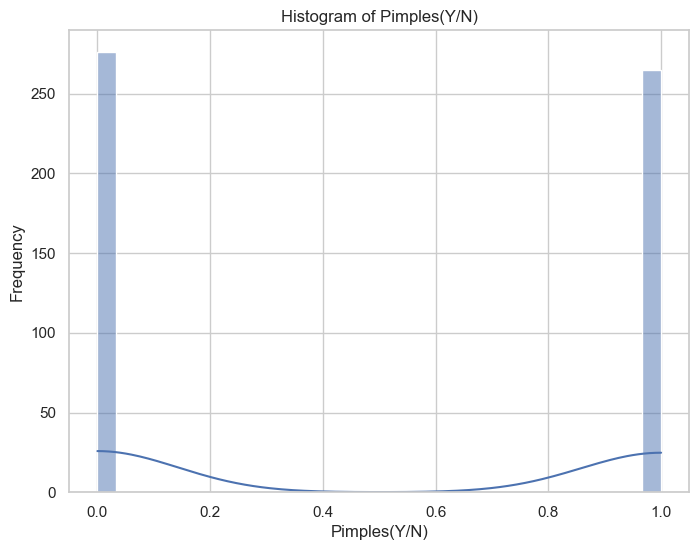

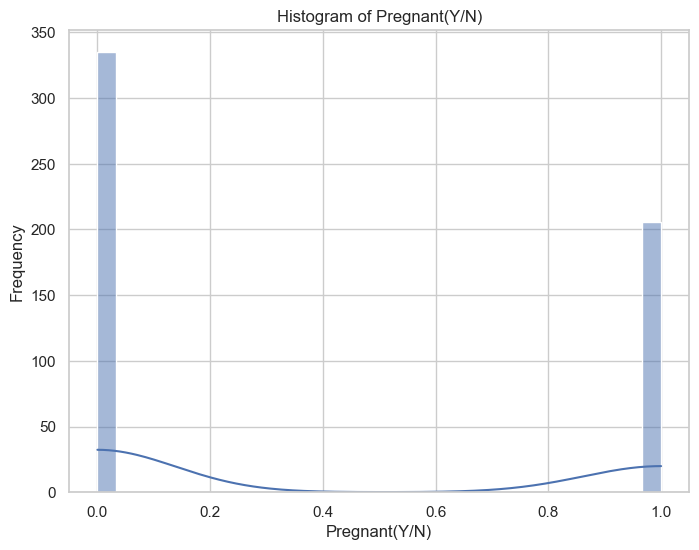

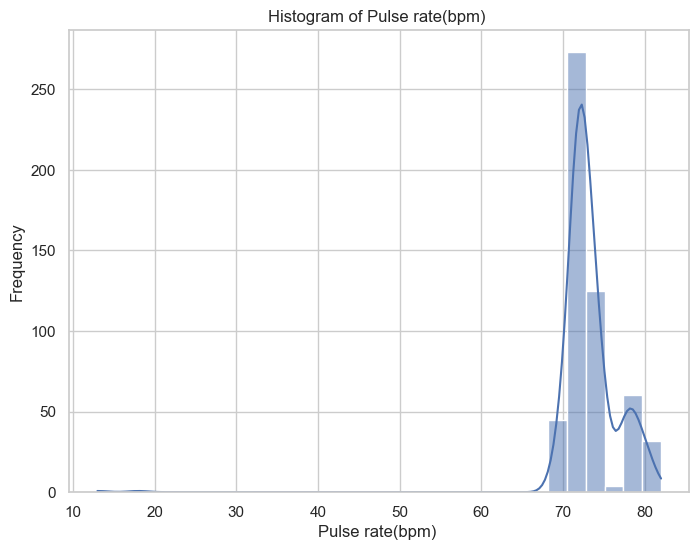

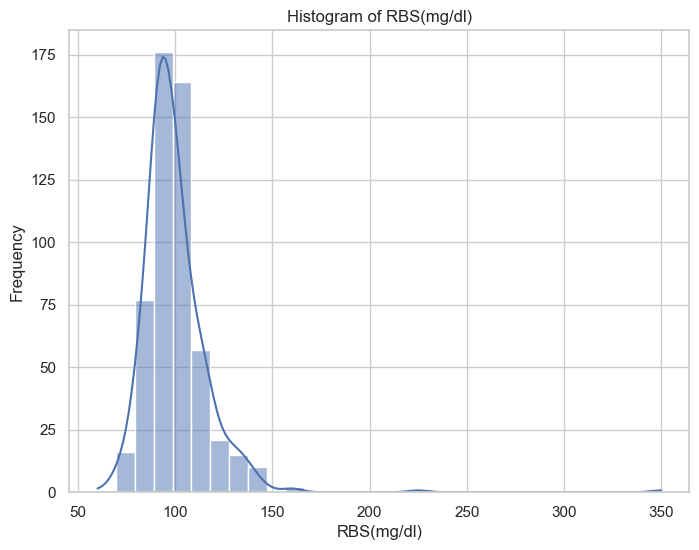

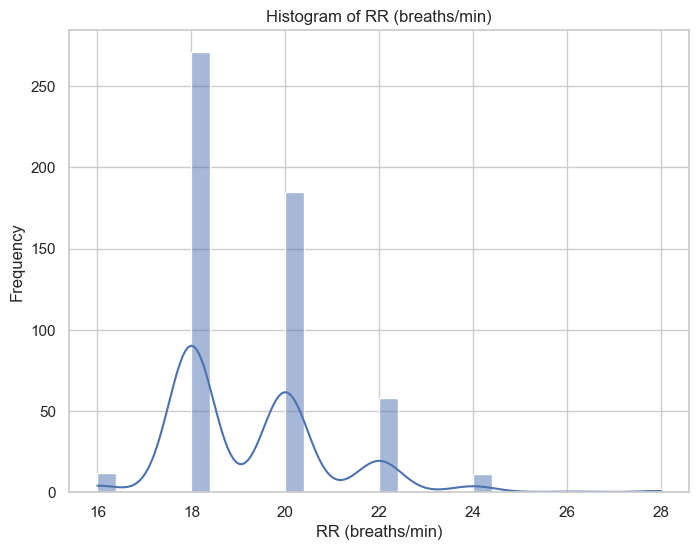

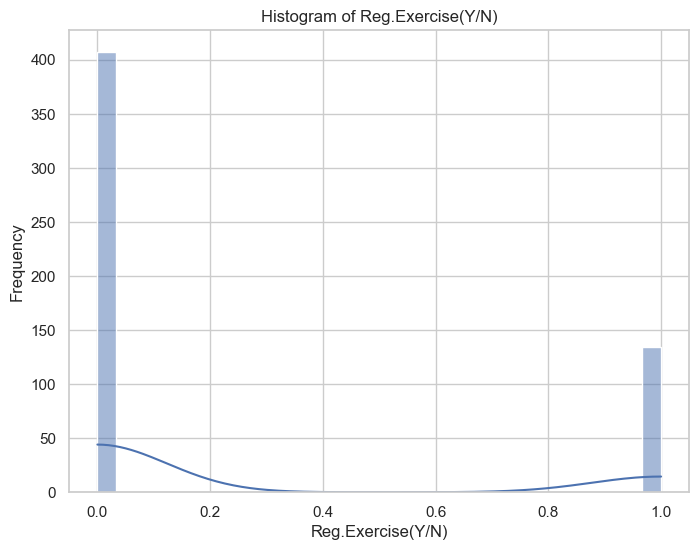

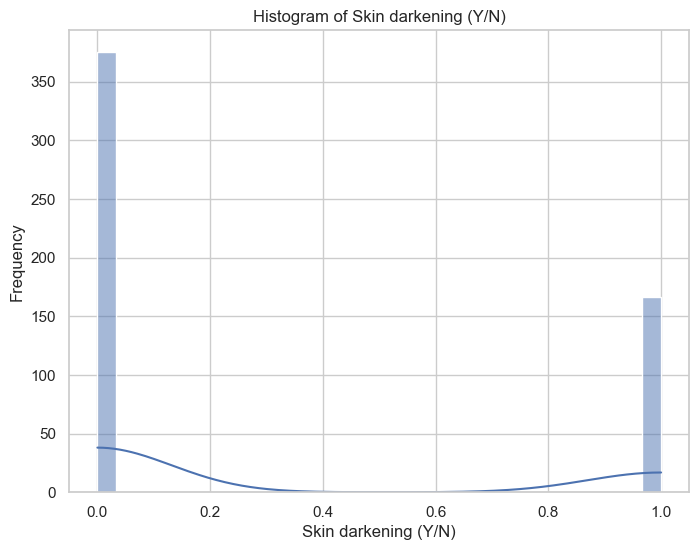

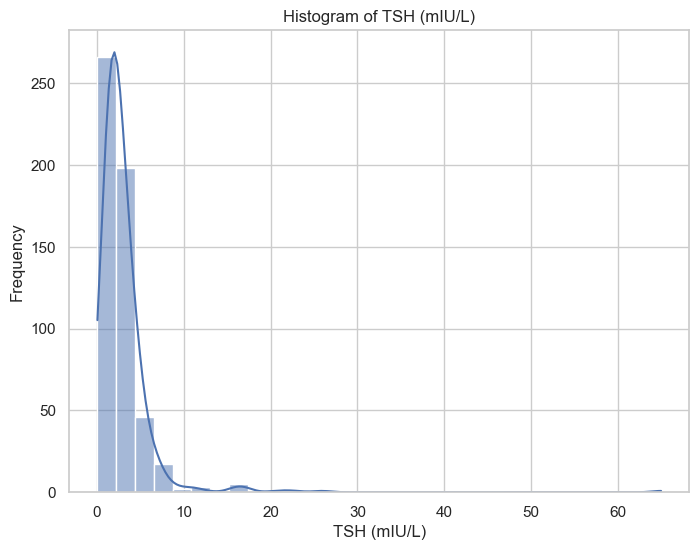

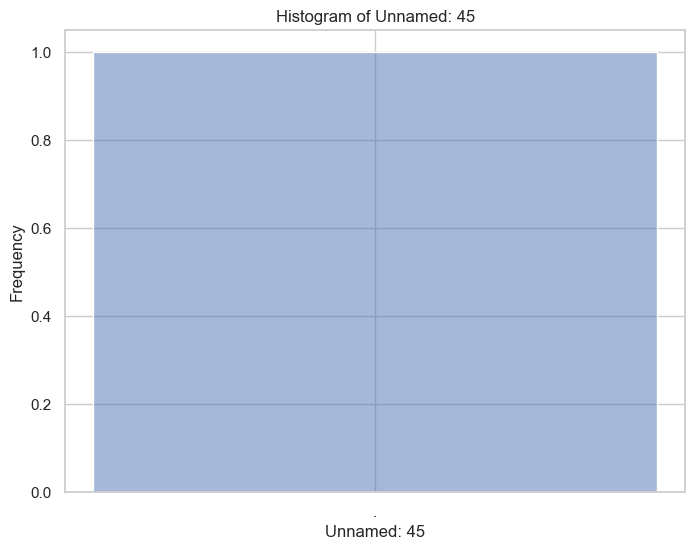

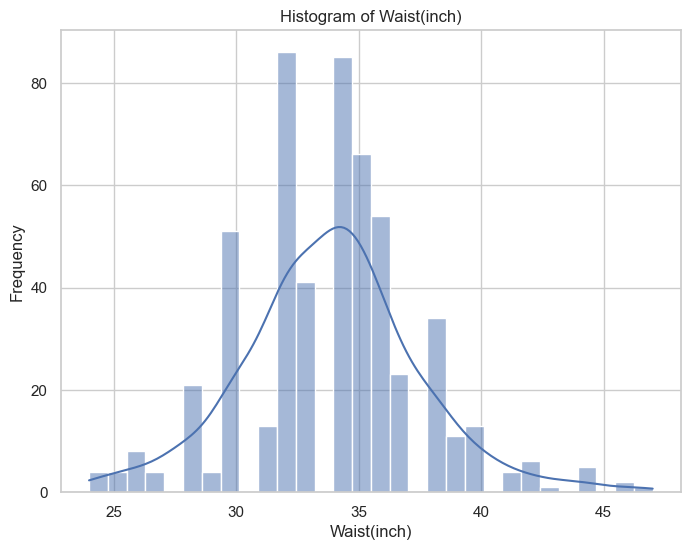

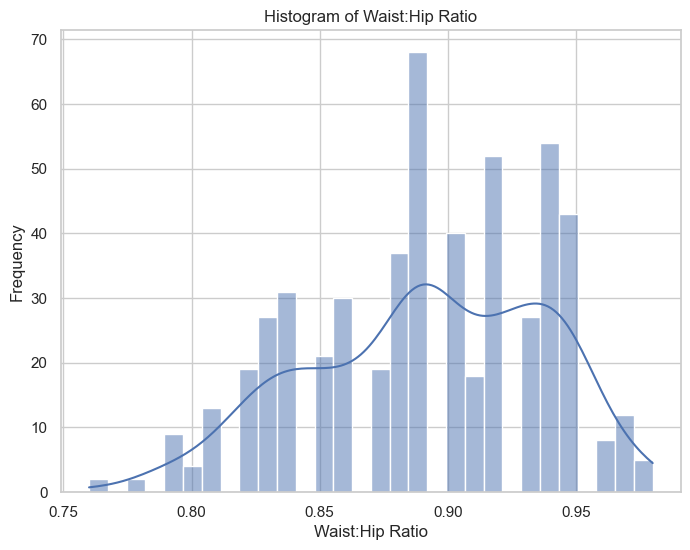

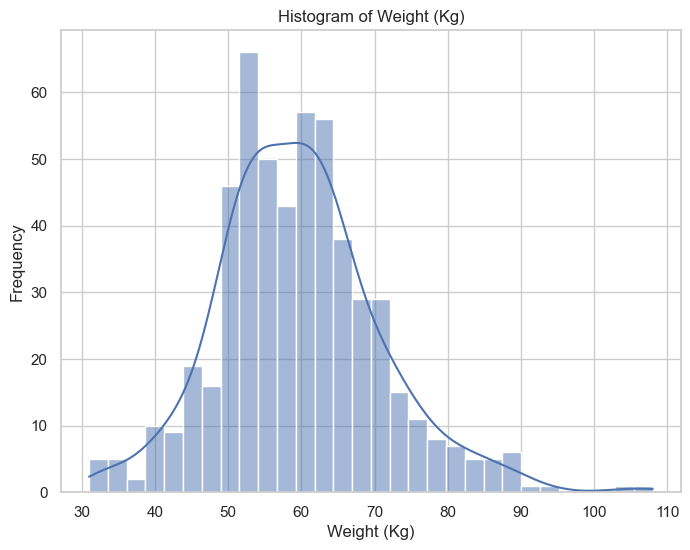

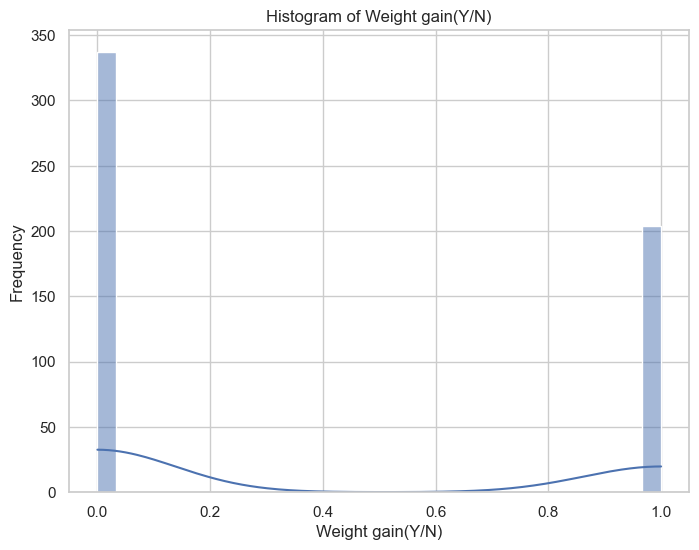

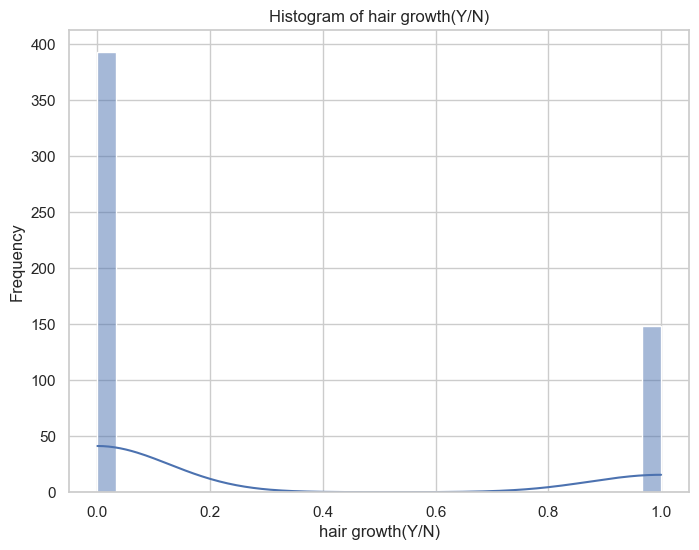

In [6]:
# VISUALIZATION
sbn.set(style="whitegrid")

# List of features to visualize (excluding the target variable)
feats = df.columns.difference(['PCOS (Y/N)', 'Sl. No', 'Patient File No.'])

# Create histograms for each feature
for feature in feats:
    pylt.figure(figsize=(8, 6))
    sbn.histplot(df[feature], bins=30, kde=True)  # kde=True adds a kernel density estimate
    pylt.title(f'Histogram of {feature}')
    pylt.xlabel(feature)
    pylt.ylabel('Frequency')
    pylt.show()

                           Sl. No  Patient File No.  PCOS (Y/N)   Age (yrs)  \
Sl. No                   1.000000          1.000000    0.060998    0.067133   
Patient File No.         1.000000          1.000000    0.060998    0.067133   
PCOS (Y/N)               0.060998          0.060998    1.000000   -0.168513   
 Age (yrs)               0.067133          0.067133   -0.168513    1.000000   
Weight (Kg)             -0.082823         -0.082823    0.211938   -0.029734   
Height(Cm)              -0.011700         -0.011700    0.068254   -0.119819   
BMI                     -0.082840         -0.082840    0.199697    0.021372   
Blood Group              0.001705          0.001705    0.036433   -0.010954   
Pulse rate(bpm)         -0.044533         -0.044533    0.091821    0.045831   
RR (breaths/min)        -0.015196         -0.015196    0.036928    0.087382   
Hb(g/dl)                -0.088681         -0.088681    0.087170   -0.021558   
Cycle(R/I)              -0.022959         -0.022959 

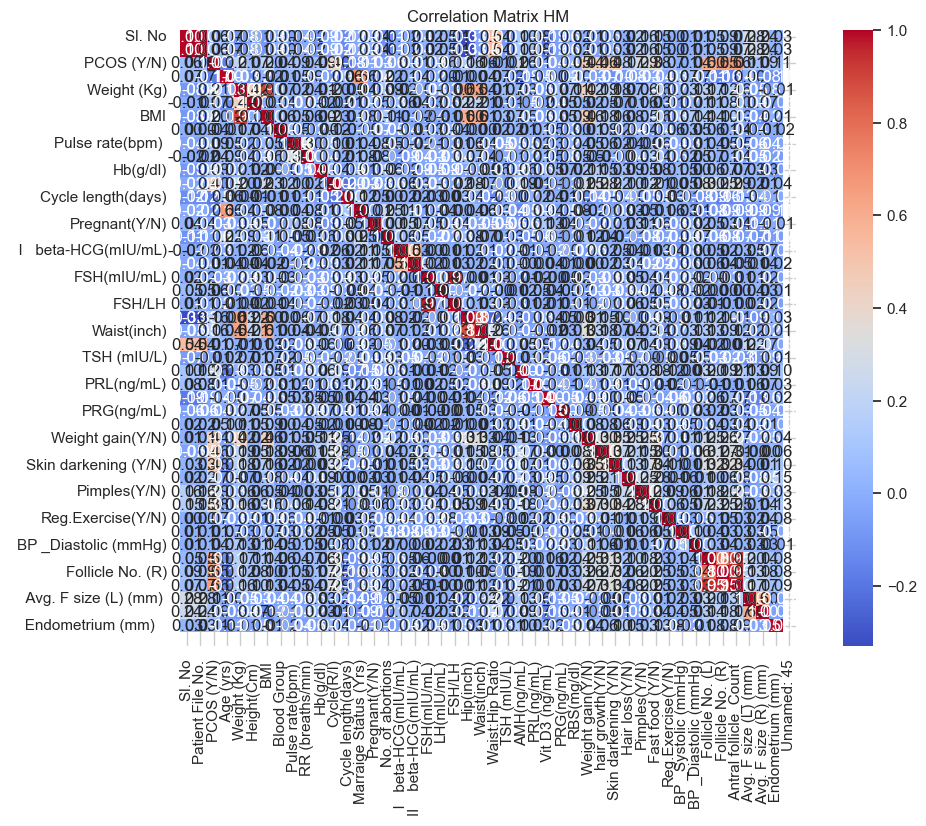

In [7]:
# Correlation Analysis
# Convert columns to numeric, errors='coerce' will replace non-numeric values with NaN
for col in df.columns:
    if df[col].dtype == 'object':  # Check if column is of object type (likely string)
        try:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        except ValueError:
            print(f"Could not convert column '{col}' to numeric. It may contain non-numeric values.")

# Now calculate the correlation matrix
corr_mat = df.corr()
print(corr_mat)
# visualizing corr mat
pylt.figure(figsize=(12, 8))
sbn.heatmap(corr_mat, annot=True, fmt=".2f", cmap='coolwarm', square=True)
pylt.title('Correlation Matrix HM')
pylt.show()

In [8]:
# DATA PREPROCESSING - DATA CLEANING
# Check for missing values
missing_vals = df.isnull().sum()
print("Missing values in each column:", missing_vals)
# Forward fill missing values if necessary-assuming the missing value is the same as the value right before it and
# vice-versa for bfill
df.ffill(inplace=True)
# Remove extra periods and convert to numeric
columns_to_clean = df.columns.difference(['PCOS (Y/N)', 'Sl. No', 'Patient File No.'])
for col in columns_to_clean:
    df[col] = df[col].astype(str).str.replace('.', '', regex=False)  # Remove periods
    df[col] = pd.to_numeric(df[col], errors='coerce')  # Convert to numeric, coercing errors to NaN
# Check for NaN values after conversion
print(df.isnull().sum())
# Fill NaNs or drop them
df.fillna(df.mean(), inplace=True)  # Fill NaNs with column's means-average
# Prepare features and target variable
# Proceed with feature selection
X = df.drop(['PCOS (Y/N)', 'Sl. No', 'Patient File No.'], axis=1)
Y = df['PCOS (Y/N)']

Missing values in each column: Sl. No                       0
Patient File No.             0
PCOS (Y/N)                   0
 Age (yrs)                   0
Weight (Kg)                  0
Height(Cm)                   0
BMI                          0
Blood Group                  0
Pulse rate(bpm)              0
RR (breaths/min)             0
Hb(g/dl)                     0
Cycle(R/I)                   0
Cycle length(days)           0
Marraige Status (Yrs)        1
Pregnant(Y/N)                0
No. of abortions             0
  I   beta-HCG(mIU/mL)       0
II    beta-HCG(mIU/mL)       0
FSH(mIU/mL)                  0
LH(mIU/mL)                   0
FSH/LH                       0
Hip(inch)                    0
Waist(inch)                  0
Waist:Hip Ratio              0
TSH (mIU/L)                  0
AMH(ng/mL)                   1
PRL(ng/mL)                   0
 Vit D3 (ng/mL)              3
PRG(ng/mL)                   0
RBS(mg/dl)                   0
Weight gain(Y/N)             0
hair gro

In [14]:
# RFE code
# Splitting the data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Drop rows with missing values
X_train_clean = X_train.dropna()
Y_train_clean = Y_train[X_train.index.isin(X_train_clean.index)]
#
#
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
# Initialize the model - RANDOM FOREST and perform RFE
RF_model = RandomForestClassifier()

# Initialize variables to track the best number of features
best_n_features = 0
best_accuracy = 0


In [20]:

# Test RFE for different numbers of features
for n_features in range(1, X.shape[1] + 1):
    rfe = RFE(estimator=RF_model, n_features_to_select=n_features)
    rfe.fit(X_train, Y_train)

    # Predict on the test set
    Y_predict = rfe.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(Y_test, Y_predict)

    # Update best features if the current accuracy is better
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_n_features = n_features

# Final RFE with the best number of features
final_rfe = RFE(estimator=RF_model, n_features_to_select=best_n_features)
final_rfe.fit(X_train, Y_train)


,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",RandomForestClassifier()
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",12
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0


In [21]:
# Convert any non-numeric columns to numeric, coercing errors to NaN
for col in X_train.columns:
    # Check if the column is not already a numeric type (int or float)
    if not pd.api.types.is_numeric_dtype(X_train[col]):
        print(f"Converting non-numeric column: {col}")
        X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
        # After coercing, check for remaining NaNs in this column and fill them
        if X_train[col].isnull().any():
            print(f"NaN values found in column '{col}' after conversion. Filling with mean.")
            # For simplicity here, we use the column mean.
            X_train[col].fillna(X_train[col].mean(), inplace=True)


In [22]:
# Apply the same conversion to X_test to maintain consistency
print("Checking X_test data types before RFE:")
print(X_test.dtypes)
for col in X_test.columns:
    if not pd.api.types.is_numeric_dtype(X_test[col]):
        print(f"Converting non-numeric column in X_test: {col}")
        X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
        # Fill NaNs in X_test using the mean from X_train to avoid data leakage
        # Ensure that the column exists in the original X_train and has a non-NaN mean
        if col in X_train.columns and not np.isnan(X_train[col].mean()):
            X_test[col].fillna(X_train[col].mean(), inplace=True)
        else:
            # Fallback if mean from X_train is NaN or column not in X_train (shouldn't happen)
            X_test[col].fillna(X_test[col].mean(), inplace=True)


Checking X_test data types before RFE:
 Age (yrs)                   int64
Weight (Kg)                  int64
Height(Cm)                   int64
BMI                          int64
Blood Group                  int64
Pulse rate(bpm)              int64
RR (breaths/min)             int64
Hb(g/dl)                     int64
Cycle(R/I)                   int64
Cycle length(days)           int64
Marraige Status (Yrs)        int64
Pregnant(Y/N)                int64
No. of abortions             int64
  I   beta-HCG(mIU/mL)       int64
II    beta-HCG(mIU/mL)       int64
FSH(mIU/mL)                  int64
LH(mIU/mL)                   int64
FSH/LH                       int64
Hip(inch)                    int64
Waist(inch)                  int64
Waist:Hip Ratio              int64
TSH (mIU/L)                  int64
AMH(ng/mL)                   int64
PRL(ng/mL)                   int64
 Vit D3 (ng/mL)              int64
PRG(ng/mL)                   int64
RBS(mg/dl)                   int64
Weight gain(Y/N)

In [23]:
# Ensure no infinite values after conversions and fillings
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_train.fillna(X_train.mean(), inplace=True)  # Fill any NaNs created by inf replacement
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)
# Use mean from X_train for filling NaNs in X_test
for col in X_test.columns:
    if X_test[col].isnull().any() and col in X_train.columns and not np.isnan(X_train[col].mean()):
        X_test[col].fillna(X_train[col].mean(), inplace=True)
    elif X_test[col].isnull().any():
        # Fallback if mean from X_train is NaN or column not in X_train
        X_test[col].fillna(X_test[col].mean(), inplace=True)
print("Finished data type conversion and NaN handling.")
print("Final X_train data types:")
print(X_train.dtypes)
print("Final X_test data types:")
print(X_test.dtypes)

Finished data type conversion and NaN handling.
Final X_train data types:
 Age (yrs)                   int64
Weight (Kg)                  int64
Height(Cm)                   int64
BMI                          int64
Blood Group                  int64
Pulse rate(bpm)              int64
RR (breaths/min)             int64
Hb(g/dl)                     int64
Cycle(R/I)                   int64
Cycle length(days)           int64
Marraige Status (Yrs)        int64
Pregnant(Y/N)                int64
No. of abortions             int64
  I   beta-HCG(mIU/mL)       int64
II    beta-HCG(mIU/mL)       int64
FSH(mIU/mL)                  int64
LH(mIU/mL)                   int64
FSH/LH                       int64
Hip(inch)                    int64
Waist(inch)                  int64
Waist:Hip Ratio              int64
TSH (mIU/L)                  int64
AMH(ng/mL)                   int64
PRL(ng/mL)                   int64
 Vit D3 (ng/mL)              int64
PRG(ng/mL)                   int64
RBS(mg/dl)      

C:\Users\Demilade\AppData\Local\Temp\ipykernel_18044\1628228536.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test[col].fillna(X_test[col].mean(), inplace=True)


In [24]:
# Get the selected features
sel_feats = X.columns[final_rfe.support_]
print("Best Number of Features:", best_n_features)
print("Best Accuracy:", best_accuracy)
print("Selected Features:")
print(sel_feats)

# Filter training and test sets to include only selected features
X_train = X_train[sel_feats]
X_test = X_test[sel_feats]

Best Number of Features: 12
Best Accuracy: 0.8899082568807339
Selected Features:
Index([' Age (yrs)', 'BMI', 'Cycle(R/I)', 'LH(mIU/mL)', 'FSH/LH', 'AMH(ng/mL)',
       'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
       'Follicle No. (L)', 'Follicle No. (R)', ' Antral follicle_Count '],
      dtype='object')


In [25]:
# Retrain model with selected feats
RF_model.fit(X_train, Y_train)

from sklearn.model_selection import GridSearchCV
# Perform Grid Search on selected feats
par_g = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20]}
g_search = GridSearchCV(estimator=RF_model, param_grid=par_g, cv=5)
# Fitting Grid Search into the training data
g_search.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 :

RF Accuracy: 0.8623853211009175
RF Confusion Matrix:
 [[71  6]
 [ 9 23]]
RF Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.92      0.90        77
           1       0.79      0.72      0.75        32

    accuracy                           0.86       109
   macro avg       0.84      0.82      0.83       109
weighted avg       0.86      0.86      0.86       109

Accuracy_RF: 0.8623853211009175


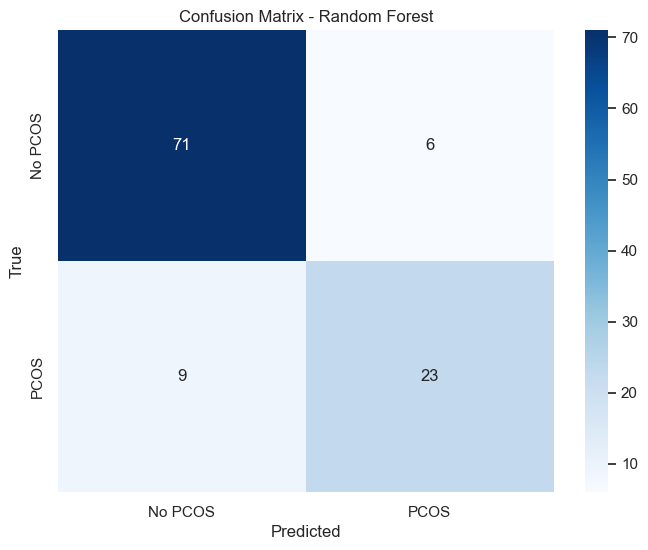

In [26]:
# Evaluation_RF
Y_predi = RF_model.predict(X_test)
print("RF Accuracy:", accuracy_score(Y_test, Y_predi))
print("RF Confusion Matrix:\n", confusion_matrix(Y_test, Y_predi))
print("RF Classification Report:\n", classification_report(Y_test, Y_predi))


def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    pylt.figure(figsize=(8, 6))
    sbn.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No PCOS', 'PCOS'],
                yticklabels=['No PCOS', 'PCOS'])
    pylt.title(f'Confusion Matrix - {model_name}')
    pylt.xlabel('Predicted')
    pylt.ylabel('True')
    pylt.show()


Y_predi = RF_model.predict(X_test)
print("Accuracy_RF:", accuracy_score(Y_test, Y_predi))
plot_confusion_matrix(Y_test, Y_predi, "Random Forest")

In [33]:
from sklearn.svm import SVC
# SUPPORT VECTOR MACHINE
SVM_model = SVC(kernel='rbf')  # You can also try other kernels like 'rbf'

# Filter training and test sets to include only selected features
X_train = X_train[sel_feats]
X_test = X_test[sel_feats]

# Retrain model with selected feats
SVM_model.fit(X_train, Y_train)
# Perform Grid Search on selected feats
par_g = {'C': [50, 100, 200], 'gamma': [None, 10, 20]}
g_search = GridSearchCV(estimator=SVM_model, param_grid=par_g, cv=5)
g_search.fit(X_train, Y_train)

C:\Users\Demilade\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
15 fits failed out of a total of 45.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Demilade\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Demilade\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\Demilade\AppData\Roa

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [50, 100, ...], 'gamma': [None, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter 

SVM Accuracy: 0.7064220183486238
SVM Confusion Matrix:
 [[77  0]
 [32  0]]
SVM Classification Report:
               precision    recall  f1-score   support

           0       0.71      1.00      0.83        77
           1       0.00      0.00      0.00        32

    accuracy                           0.71       109
   macro avg       0.35      0.50      0.41       109
weighted avg       0.50      0.71      0.58       109

Accuracy_SVM: 0.7064220183486238


C:\Users\Demilade\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Demilade\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Demilade\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

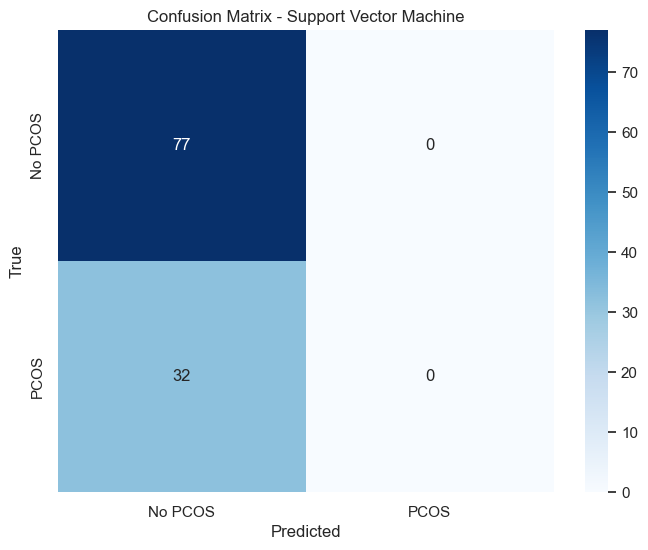

In [34]:
# Evaluation_SVM
Y_predi = SVM_model.predict(X_test)
print("SVM Accuracy:", accuracy_score(Y_test, Y_predi))
print("SVM Confusion Matrix:\n", confusion_matrix(Y_test, Y_predi))
print("SVM Classification Report:\n", classification_report(Y_test, Y_predi))

# Confusion Matrix SVM
Y_predi = SVM_model.predict(X_test)
print("Accuracy_SVM:", accuracy_score(Y_test, Y_predi))
plot_confusion_matrix(Y_test, Y_predi, "Support Vector Machine")


In [35]:
from sklearn.linear_model import LogisticRegression
# LOGISTIC REGRESSION
LR_model = LogisticRegression(max_iter=10000, solver='saga')

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

LR_model.fit(X_train, Y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Accuracy: 0.7064220183486238
Confusion Matrix:
 [[75  2]
 [30  2]]
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.97      0.82        77
           1       0.50      0.06      0.11        32

    accuracy                           0.71       109
   macro avg       0.61      0.52      0.47       109
weighted avg       0.65      0.71      0.61       109

Accuracy_LR: 0.5137614678899083


C:\Users\Demilade\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


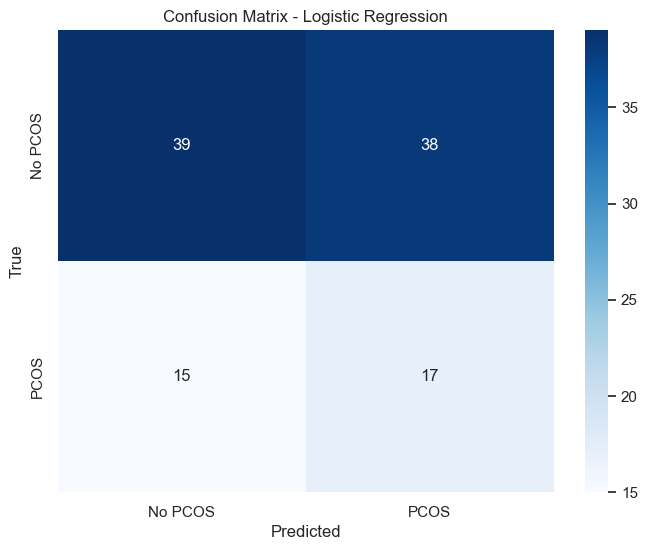

In [36]:
# Evaluation_LR
Y_predi = LR_model.predict(X_test)
print("Accuracy:", accuracy_score(Y_test, Y_predi))
print("Confusion Matrix:\n", confusion_matrix(Y_test, Y_predi))
print("Classification Report:\n", classification_report(Y_test, Y_predi))

# Confusion Matrix
Y_predi = LR_model.predict(X_test_scaled)
print("Accuracy_LR:", accuracy_score(Y_test, Y_predi))
plot_confusion_matrix(Y_test, Y_predi, "Logistic Regression")

In [37]:
# Cross-Validation SCORES
RF_scores = cross_val_score(RF_model, X_train, Y_train, cv=10)
LR_scores = cross_val_score(LR_model, X_train, Y_train, cv=10)
SVM_scores = cross_val_score(SVM_model, X_train, Y_train, cv=10)

print(f"RF Cross-Validation Scores: {RF_scores}")
print(f"LR Cross-Validation Scores: {LR_scores}")
print(f"SVM Cross-Validation Scores: {SVM_scores}")
print(f"RF Mean Accuracy: {RF_scores.mean():.2f} ± {RF_scores.std():.2f}")
print(f"LR Mean Accuracy: {LR_scores.mean():.2f} ± {LR_scores.std():.2f}")
print(f"SVM Mean Accuracy: {SVM_scores.mean():.2f} ± {SVM_scores.std():.2f}")

RF Cross-Validation Scores: [0.90909091 0.93181818 0.88372093 0.93023256 0.95348837 0.95348837
 0.88372093 0.8372093  0.93023256 0.88372093]
LR Cross-Validation Scores: [0.63636364 0.59090909 0.62790698 0.76744186 0.65116279 0.6744186
 0.6744186  0.6744186  0.65116279 0.6744186 ]
SVM Cross-Validation Scores: [0.65909091 0.65909091 0.65116279 0.65116279 0.65116279 0.6744186
 0.6744186  0.6744186  0.6744186  0.6744186 ]
RF Mean Accuracy: 0.91 ± 0.04
LR Mean Accuracy: 0.66 ± 0.04
SVM Mean Accuracy: 0.66 ± 0.01


In [49]:
# Save model as a new file and selected features
joblib.dump((RF_model, sel_feats), 'PCOS_rf_MOD2.pkl')
joblib.dump((LR_model, sel_feats), 'PCOS_lr_MOD2.pkl')
joblib.dump((SVM_model, sel_feats), 'PCOS_svm_MOD2.pkl')

['PCOS_svm_MOD2.pkl']

In [50]:

# Input data
RF_model, sel_feats = joblib.load('PCOS_rf_MOD2.pkl')
LR_model, sel_feats = joblib.load('PCOS_lr_MOD2.pkl')
SVM_model, sel_feats = joblib.load('PCOS_svm_MOD2.pkl')

input_values = [[20, 84, 30.3, 2, 7.86, 2.90, 2.71, 2.10, 30.07, 1, 1, 0]]
input_df = pd.DataFrame(input_values, columns=sel_feats)


In [ ]:
# Make a prediction - RF
prediction = RF_model.predict(input_df)

if prediction == 0:
    print("PCOS Prediction (RF): PCOS is not present")
else:
    print("PCOS Prediction (RF): PCOS is present")


PCOS Prediction: PCOS is not present


In [51]:

# Make a prediction - LR
prediction = LR_model.predict(input_df)

if prediction == 0:
    print("PCOS Prediction (LR): PCOS is not present")
else:
    print("PCOS Prediction (LR): PCOS is present")


PCOS Prediction (LR): PCOS is not present


In [52]:
# Make a prediction - SVM
prediction = SVM_model.predict(input_df)

if prediction == 0:
    print("PCOS Prediction (SVM): PCOS is not present")
else:
    print("PCOS Prediction (SVM): PCOS is present")


PCOS Prediction (SVM): PCOS is not present
